# 07 - Strategic Dataset Training

Train baseline transformer on strategically filtered discard dataset.

Dataset:
- discard/strategic.db

Goal:
- evaluate effect of removing trivial states
- compare strategic metrics
- analyze policy quality changes

In [14]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [15]:
import torch

from torch.utils.data import DataLoader

from tqdm import tqdm

In [16]:
from src.data.dataset import (
    MahjongDataset
)

from src.data.collator import (
    MahjongCollator
)

from src.models.transformer_model import (
    MahjongTransformer
)

In [17]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [18]:
train_dataset = MahjongDataset(
    db_path="../data/discard/strategic.db",

    limit=500000,
)

In [19]:
collator = MahjongCollator()

In [20]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    collate_fn=collator.collate,

    num_workers=4,

    pin_memory=True,
)

In [21]:
model = MahjongTransformer(

    embedding_dim=128,

    num_heads=8,

    num_layers=4,

    ff_dim=512,
).to(device)

In [22]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
)

In [23]:
NUM_EPOCHS = 8

In [25]:
train_losses = []

train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(train_loader)

    for batch in progress_bar:

        # ============================================
        # MOVE BATCH TO DEVICE
        # ============================================

        moved = {}

        for key, value in batch.items():

            if isinstance(value, list):

                moved[key] = [
                    v.to(device)
                    for v in value
                ]

            elif torch.is_tensor(value):

                moved[key] = value.to(device)

            else:

                moved[key] = value

        batch = moved

        # ============================================
        # ZERO GRAD
        # ============================================

        optimizer.zero_grad()

        # ============================================
        # FORWARD
        # ============================================

        logits_list = model(batch)

        # ============================================
        # LOSS
        # ============================================

        losses = []

        predictions = []

        for i, logits in enumerate(logits_list):

            target = batch[
                "target"
            ][i]

            loss = torch.nn.functional.cross_entropy(

                logits.unsqueeze(0),

                target.unsqueeze(0),
            )

            losses.append(loss)

            prediction = torch.argmax(
                logits
            )

            predictions.append(
                prediction
            )

        batch_loss = torch.stack(
            losses
        ).mean()

        # ============================================
        # BACKPROP
        # ============================================

        batch_loss.backward()

        optimizer.step()

        # ============================================
        # METRICS
        # ============================================

        total_loss += batch_loss.item()

        predictions = torch.stack(
            predictions
        )

        correct = (
            predictions
            ==
            batch["target"]
        ).sum().item()

        total_correct += correct

        total_samples += len(
            predictions
        )

        # ============================================
        # PROGRESS BAR
        # ============================================

        progress_bar.set_description(

            f"Epoch {epoch+1} | "
            f"Loss {batch_loss.item():.4f}"
        )

    # ================================================
    # EPOCH METRICS
    # ================================================

    train_loss = (
        total_loss
        /
        len(train_loader)
    )

    train_accuracy = (
        total_correct
        /
        total_samples
    )

    print()

    print(
        f"Epoch {epoch+1}"
    )

    print(
        f"Train Loss: "
        f"{train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy:.4f}"
    )

    checkpoint_path = (

        f"../checkpoints/strategic_500k/"
        f"epoch_{epoch+1}.pt"
    )

    torch.save({

        "epoch":
            epoch + 1,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            train_loss,

        "train_accuracy":
            train_accuracy,

    }, checkpoint_path)

    print(
        f"Saved checkpoint: "
        f"{checkpoint_path}"
    )

    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

Epoch 1 | Loss 1.5681: 100%|██████████| 7813/7813 [49:53<00:00,  2.61it/s] 



Epoch 1
Train Loss: 1.4013
Train Accuracy: 0.5396
Saved checkpoint: ../checkpoints/strategic_500k/epoch_1.pt


Epoch 2 | Loss 1.1379: 100%|██████████| 7813/7813 [49:36<00:00,  2.62it/s] 



Epoch 2
Train Loss: 1.2814
Train Accuracy: 0.5689
Saved checkpoint: ../checkpoints/strategic_500k/epoch_2.pt


Epoch 3 | Loss 1.2260: 100%|██████████| 7813/7813 [49:59<00:00,  2.60it/s] 


...


Epoch 6
Train Loss: 1.0408
Train Accuracy: 0.6290
Saved checkpoint: ../checkpoints/strategic_500k/epoch_6.pt


Epoch 7 | Loss 0.8355: 100%|██████████| 7813/7813 [49:32<00:00,  2.63it/s]



Epoch 7
Train Loss: 1.0159
Train Accuracy: 0.6364
Saved checkpoint: ../checkpoints/strategic_500k/epoch_7.pt


Epoch 8 | Loss 0.8933: 100%|██████████| 7813/7813 [49:51<00:00,  2.61it/s]  


Epoch 8
Train Loss: 0.9957
Train Accuracy: 0.6423
Saved checkpoint: ../checkpoints/strategic_500k/epoch_8.pt


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [28]:
history_df = pd.DataFrame({

    "epoch": list(
        range(
            1,
            NUM_EPOCHS + 1
        )
    ),

    "train_loss":
        train_losses,

    "train_accuracy":
        train_accuracies,
})

history_df

,epoch,train_loss,train_accuracy
0,1,1.401312,0.539632
1,2,1.281375,0.568914
2,3,1.183528,0.591432
3,4,1.114909,0.608474
4,5,1.072144,0.619452
5,6,1.040778,0.628968
6,7,1.015939,0.636392
7,8,0.995681,0.642334


In [29]:
sns.set_theme(
    style="whitegrid"
)

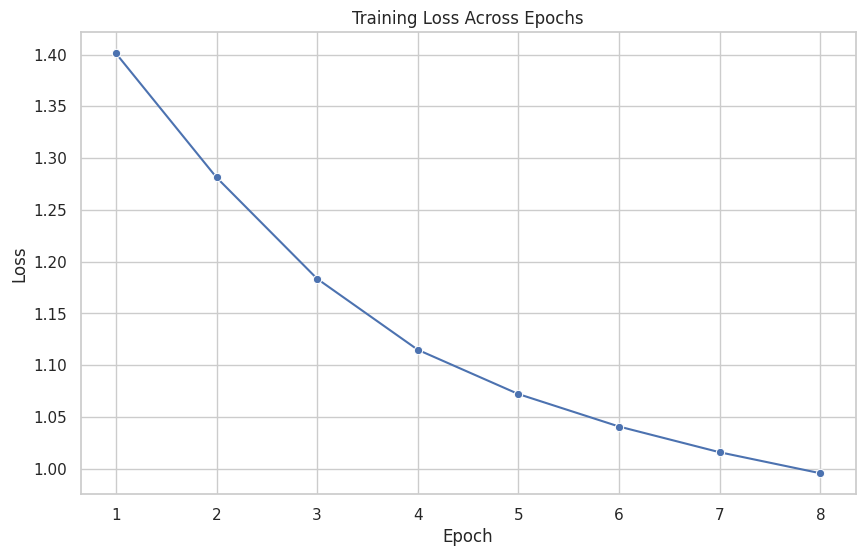

In [30]:
plt.figure(figsize=(10, 6))

sns.lineplot(

    data=history_df,

    x="epoch",

    y="train_loss",

    marker="o",
)

plt.title(
    "Training Loss Across Epochs"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [35]:
plt.savefig(

    "../reports/figures/training_loss.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

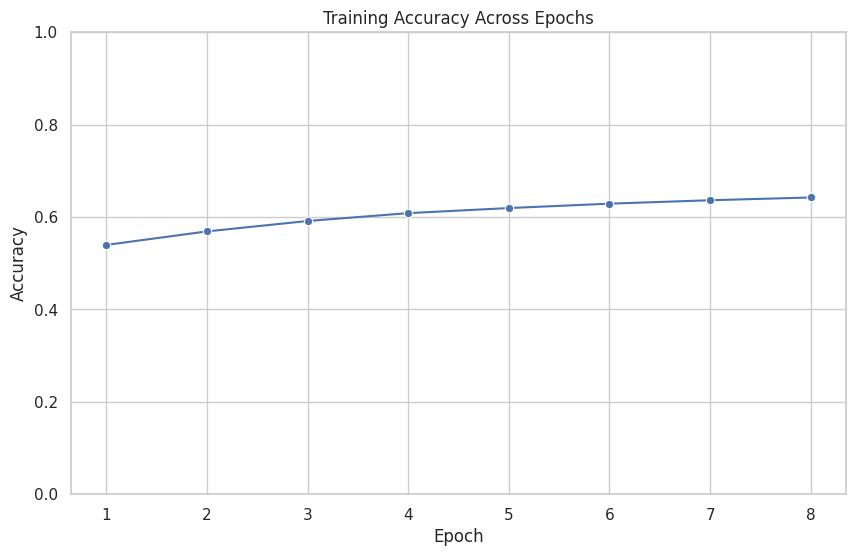

In [31]:
plt.figure(figsize=(10, 6))

sns.lineplot(

    data=history_df,

    x="epoch",

    y="train_accuracy",

    marker="o",
)

plt.title(
    "Training Accuracy Across Epochs"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

In [36]:
plt.savefig(

    "../reports/figures/training_accuracy.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

In [32]:
history_long = pd.melt(

    history_df,

    id_vars="epoch",

    value_vars=[
        "train_loss",
        "train_accuracy",
    ],

    var_name="metric",

    value_name="value",
)

history_long.head()

,epoch,metric,value
0,1,train_loss,1.401312
1,2,train_loss,1.281375
2,3,train_loss,1.183528
3,4,train_loss,1.114909
4,5,train_loss,1.072144


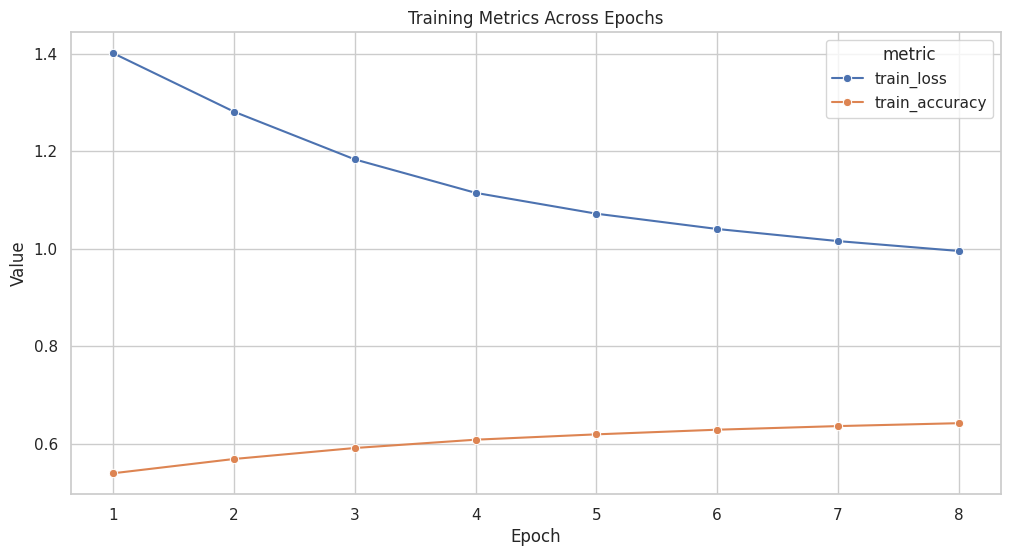

In [33]:
plt.figure(figsize=(12, 6))

sns.lineplot(

    data=history_long,

    x="epoch",

    y="value",

    hue="metric",

    marker="o",
)

plt.title(
    "Training Metrics Across Epochs"
)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.show()

In [34]:
history_df.to_csv(

    "../reports/training_history.csv",

    index=False,
)

print("Saved training history.")

Saved training history.
